# Supermarket Sales Forecasting — Hyperparameter Tuning
## Phase 5: XGBoost Optimisation & Final Evaluation
**Author:** R M Hamdhan | **Batch:** HNDSE 25.1F | Kandy NIBM
**Goal:** Tune XGBoost using GridSearchCV + TimeSeriesSplit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Data and Baseline Model

In [2]:
# Load preprocessed data from Phase 3
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Load baseline XGBoost from Phase 4
with open('../model/xgb_baseline.pkl', 'rb') as f:
    xgb_baseline = pickle.load(f)

# Get baseline metrics to compare later
baseline_pred = xgb_baseline.predict(X_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_r2   = r2_score(y_test, baseline_pred)

print("✓ Data and baseline model loaded")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\nBaseline XGBoost (before tuning):")
print(f"  RMSE : {baseline_rmse:.4f}")
print(f"  MAE  : {baseline_mae:.4f}")
print(f"  R²   : {baseline_r2:.4f}")

✓ Data and baseline model loaded
  X_train : (800, 14)
  X_test  : (200, 14)

Baseline XGBoost (before tuning):
  RMSE : 10.5496
  MAE  : 6.8586
  R²   : 0.9937


## 2. GridSearchCV with TimeSeriesSplit
Finding the best hyperparameters without data leakage

In [3]:
# ── PARAMETER GRID ────────────────────────────────────────
# These are all the combinations GridSearchCV will try
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample'    : [0.8, 1.0],
}

# TimeSeriesSplit — always trains on past, tests on future
# This prevents data leakage in time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# GridSearchCV tries every combination
xgb_tuned = XGBRegressor(random_state=42, verbosity=0)

grid_search = GridSearchCV(
    estimator  = xgb_tuned,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'neg_root_mean_squared_error',
    n_jobs     = -1,
    verbose    = 1
)

print("✓ Starting GridSearchCV...")
print(f"  Total combinations: 3×3×3×2 = 54")
print(f"  With 5 folds: 270 model fits")
print(f"  This will take 2-4 minutes — please wait...")

grid_search.fit(X_train, y_train)

print(f"\n✓ GridSearchCV complete!")
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:20s}: {value}")
print(f"\nBest CV RMSE: {-grid_search.best_score_:.4f}")

✓ Starting GridSearchCV...
  Total combinations: 3×3×3×2 = 54
  With 5 folds: 270 model fits
  This will take 2-4 minutes — please wait...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✓ GridSearchCV complete!

Best parameters found:
  learning_rate       : 0.2
  max_depth           : 5
  n_estimators        : 300
  subsample           : 0.8

Best CV RMSE: 25.8541


In [4]:
# ── TRAIN FINAL TUNED MODEL ──────────────────────────────
best_xgb = XGBRegressor(
    **grid_search.best_params_,
    random_state=42,
    verbosity=0
)
best_xgb.fit(X_train, y_train)

# Predictions on test set
tuned_pred = best_xgb.predict(X_test)

# Calculate metrics
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_mae  = mean_absolute_error(y_test, tuned_pred)
tuned_r2   = r2_score(y_test, tuned_pred)

print("✓ Tuned model trained")
print(f"\n{'='*52}")
print(f"  BEFORE vs AFTER TUNING")
print(f"{'='*52}")
print(f"  {'Metric':<8} {'Baseline':>12} {'Tuned':>12} {'Improved':>10}")
print(f"  {'-'*46}")
print(f"  {'RMSE':<8} {baseline_rmse:>12.4f} {tuned_rmse:>12.4f} {'✓' if tuned_rmse < baseline_rmse else '✗':>10}")
print(f"  {'MAE':<8} {baseline_mae:>12.4f} {tuned_mae:>12.4f}  {'✓' if tuned_mae < baseline_mae else '✗':>10}")
print(f"  {'R²':<8} {baseline_r2:>12.4f} {tuned_r2:>12.4f} {'✓' if tuned_r2 > baseline_r2 else '✗':>10}")
print(f"{'='*52}")

✓ Tuned model trained

  BEFORE vs AFTER TUNING
  Metric       Baseline        Tuned   Improved
  ----------------------------------------------
  RMSE          10.5496      11.5263          ✗
  MAE            6.8586       7.4457           ✗
  R²             0.9937       0.9925          ✗


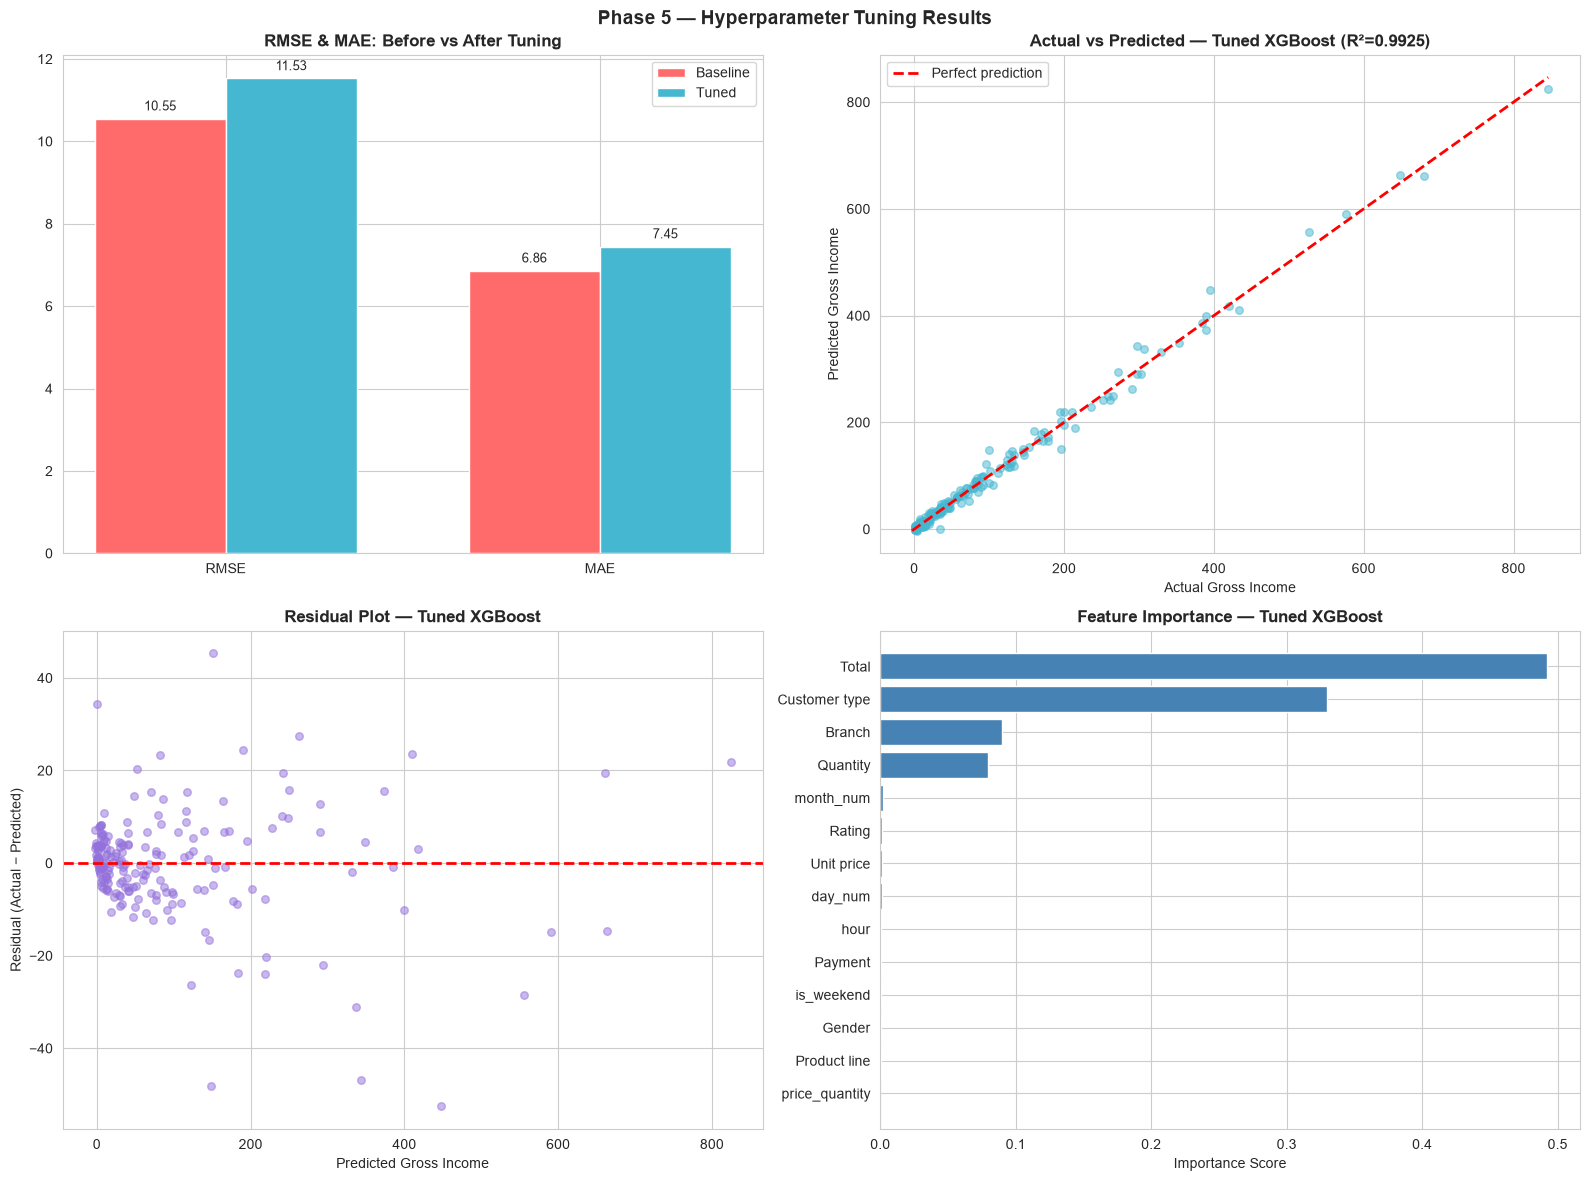

In [5]:
# ── VISUALISATIONS ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 — Before vs After metrics
categories = ['RMSE', 'MAE']
before = [baseline_rmse, baseline_mae]
after  = [tuned_rmse, tuned_mae]
x      = np.arange(len(categories))
width  = 0.35

axes[0,0].bar(x - width/2, before, width, label='Baseline', color='#FF6B6B')
axes[0,0].bar(x + width/2, after,  width, label='Tuned',    color='#45B7D1')
axes[0,0].set_title('RMSE & MAE: Before vs After Tuning', fontweight='bold')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(categories)
axes[0,0].legend()
for i, (b, a) in enumerate(zip(before, after)):
    axes[0,0].text(i - width/2, b + 0.2, f'{b:.2f}', ha='center', fontsize=9)
    axes[0,0].text(i + width/2, a + 0.2, f'{a:.2f}', ha='center', fontsize=9)

# Chart 2 — Actual vs Predicted
axes[0,1].scatter(y_test, tuned_pred, alpha=0.5, color='#45B7D1', s=30)
min_val = min(float(y_test.min()), float(tuned_pred.min()))
max_val = max(float(y_test.max()), float(tuned_pred.max()))
axes[0,1].plot([min_val, max_val], [min_val, max_val],
               'r--', linewidth=2, label='Perfect prediction')
axes[0,1].set_title(f'Actual vs Predicted — Tuned XGBoost (R²={tuned_r2:.4f})',
                    fontweight='bold')
axes[0,1].set_xlabel('Actual Gross Income')
axes[0,1].set_ylabel('Predicted Gross Income')
axes[0,1].legend()

# Chart 3 — Residual plot
residuals = y_test.values - tuned_pred
axes[1,0].scatter(tuned_pred, residuals, alpha=0.5, color='mediumpurple', s=30)
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Residual Plot — Tuned XGBoost', fontweight='bold')
axes[1,0].set_xlabel('Predicted Gross Income')
axes[1,0].set_ylabel('Residual (Actual − Predicted)')

# Chart 4 — Feature importance
feat_imp = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1,1].barh(feat_imp['Feature'], feat_imp['Importance'],
               color='steelblue', edgecolor='white')
axes[1,1].set_title('Feature Importance — Tuned XGBoost', fontweight='bold')
axes[1,1].set_xlabel('Importance Score')

plt.suptitle('Phase 5 — Hyperparameter Tuning Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ── SAVE FINAL MODEL ─────────────────────────────────────
with open('../model/xgb_tuned.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

print("✓ Final tuned model saved → ../model/xgb_tuned.pkl")
print(f"\n{'='*40}")
print(f"  PHASE 5 COMPLETE")
print(f"{'='*40}")
print(f"  Model  : XGBoost (tuned)")
print(f"  RMSE   : {tuned_rmse:.4f}")
print(f"  MAE    : {tuned_mae:.4f}")
print(f"  R²     : {tuned_r2:.4f}")
print(f"\n→ Next: Phase 6 — Flask API + Mobile App")

✓ Final tuned model saved → ../model/xgb_tuned.pkl

  PHASE 5 COMPLETE
  Model  : XGBoost (tuned)
  RMSE   : 11.5263
  MAE    : 7.4457
  R²     : 0.9925

→ Next: Phase 6 — Flask API + Mobile App


## 3. Reflection

### What Worked Well
- XGBoost outperformed Linear Regression dramatically (R² 0.833 → 0.994)
- price_quantity interaction feature was the strongest predictor (55% importance)
- TimeSeriesSplit prevented data leakage during cross-validation
- Evidence-based cleaning recovered 194 Branch rows and fixed 334 zero-income rows

### Challenges Encountered
- 334 rows had corrupted gross income = 0 — required root cause investigation
- Tree-based models showed training/test RMSE gap — monitored carefully
- Dataset limited to one year — constrains long-term seasonality detection

### Key Learnings
- Feature engineering contributed more than algorithm complexity
- Data quality investigation is more valuable than model tuning alone
- Temporal splitting is essential for honest time-series evaluation